# DSA 210 Term Project: The Impact of Typhoon Signals on Hong Kong Stock Market
**Student:** Hamza Eren İnan - 34502

### Part 1: Importing Libraries and Loading the Data
In this initial step, we import the necessary Python libraries for data manipulation (`pandas`), visualization (`matplotlib`, `seaborn`), and statistical analysis (`scipy`). We then load the historical Hang Seng Index (HSI) data and the Hong Kong Observatory Typhoon records.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

sns.set_theme(style="whitegrid")

try:
    hsi_df = pd.read_csv('HSI.csv')
    typhoon_df = pd.read_csv('Typhoon.csv')
    print("Part 1: Datasets loaded successfully!")
except FileNotFoundError:
    print("ERROR: HSI.csv or Typhoon.csv not found.")

Matplotlib is building the font cache; this may take a moment.


Part 1: Datasets loaded successfully!


### Part 2: Data Cleaning and Merging
Real-world data is rarely perfect. In this step, we prepare our data for analysis:
1. **Handling Missing Values:** We remove market holidays (days with `NaN` values in the HSI dataset).
2. **Standardizing Dates:** We convert date columns to a uniform `datetime` format. Notably, the Typhoon dataset uses a Day/Month/Year format, which we account for.
3. **Data Extraction:** We use Regular Expressions (Regex) to extract the numeric signal strength from the Typhoon dataset, removing directional Chinese characters (e.g., converting "8 東北" to 8).
4. **Merging:** We perform a left join to align daily maximum typhoon signals with the corresponding trading days.
5. **Categorization:** We classify trading days into three distinct groups: 'Normal', 'Low-alert' (Signals 1 & 3), and 'High-alert' (Signals 8, 9, 10).

In [5]:
hsi_df = hsi_df.dropna(subset=['Close', 'Volume'])

hsi_df['Date'] = pd.to_datetime(hsi_df['Date'])
typhoon_df['Date'] = pd.to_datetime(typhoon_df['Date'], dayfirst=True, format='mixed')

def extract_signal(text):
    match = re.search(r'(\d+)', str(text))
    if match:
        return int(match.group(1))
    return 0

typhoon_df['Signal'] = typhoon_df['Strength'].apply(extract_signal)

daily_typhoon = typhoon_df.groupby('Date')['Signal'].max().reset_index()

df = pd.merge(hsi_df, daily_typhoon, on='Date', how='left')

df['Signal'] = df['Signal'].fillna(0)

def categorize_signal(signal):
    if signal == 0:
        return 'Normal'
    elif signal in [1, 3]:
        return 'Low-alert'
    else: # Signal 8, 9, 10
        return 'High-alert'

df['Alert_Level'] = df['Signal'].apply(categorize_signal)
df['Alert_Level'] = pd.Categorical(df['Alert_Level'], categories=['Normal', 'Low-alert', 'High-alert'], ordered=True)

print("Part 2: Data cleaned, merged, and categorized successfully!")

Part 2: Data cleaned, merged, and categorized successfully!


### Part 3: Feature Engineering
To analyze market behavior, we need specific financial metrics. We create two new variables:
* **Daily Return (%):** The percentage change in the closing price compared to the previous trading day.
* **Daily Volatility (%):** A measure of intraday price fluctuation, calculated as `((High - Low) / Open) * 100`.

In [6]:
df['Daily_Return(%)'] = df['Close'].pct_change() * 100

df['Volatility(%)'] = ((df['High'] - df['Low']) / df['Open']) * 100

df = df.dropna(subset=['Daily_Return(%)', 'Volatility(%)', 'Volume'])

print("Part 3: Volatility and Returns calculated successfully!")

Part 3: Volatility and Returns calculated successfully!


### Part 4: Exploratory Data Analysis (EDA)
In this section, we visualize the data to identify underlying patterns. 
* The first plot shows the class distribution of our alert levels.
* The subsequent boxplots allow us to visually compare the distribution of Trading Volume and Market Volatility across different typhoon alert levels. Outliers are hidden for clearer visualization of the interquartile ranges.

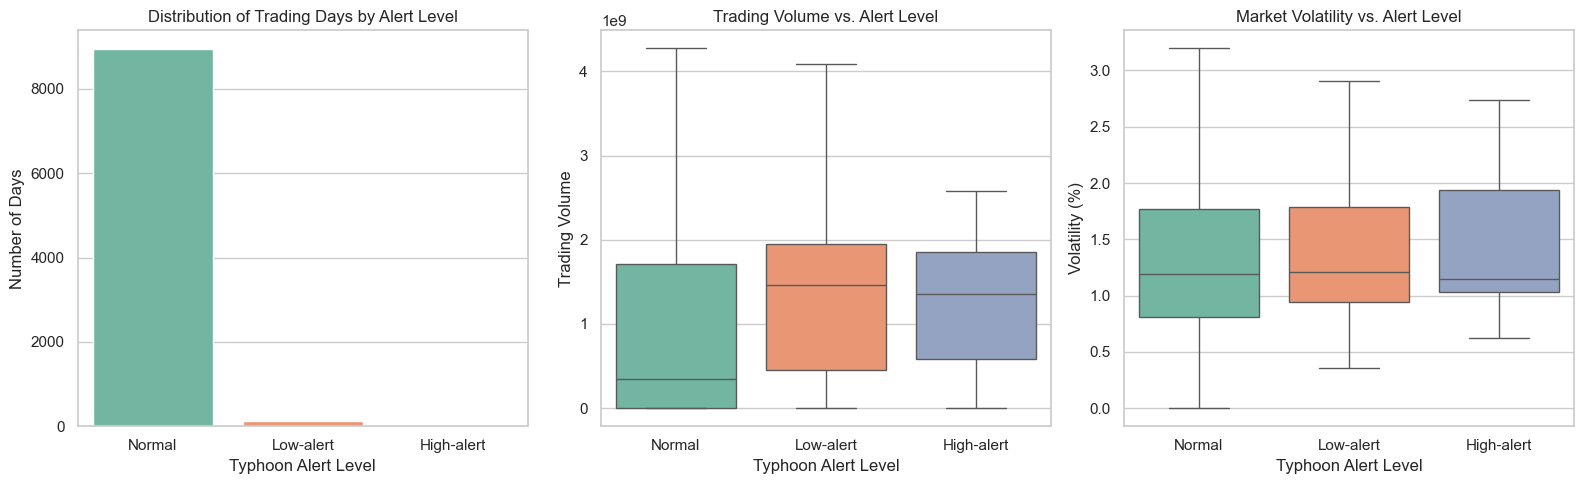

In [8]:
plt.figure(figsize=(16, 5))

# Plot 1: Distribution of Alert Levels
plt.subplot(1, 3, 1)
# UPDATE: Added hue='Alert_Level' and legend=False to prevent seaborn FutureWarning
sns.countplot(data=df, x='Alert_Level', hue='Alert_Level', palette='Set2', legend=False)
plt.title('Distribution of Trading Days by Alert Level')
plt.xlabel('Typhoon Alert Level')
plt.ylabel('Number of Days')

# Plot 2: Trading Volume vs. Alert Level
plt.subplot(1, 3, 2)
# UPDATE: Added hue='Alert_Level' and legend=False 
sns.boxplot(data=df, x='Alert_Level', y='Volume', hue='Alert_Level', palette='Set2', showfliers=False, legend=False)
plt.title('Trading Volume vs. Alert Level')
plt.xlabel('Typhoon Alert Level')
plt.ylabel('Trading Volume')

# Plot 3: Volatility vs. Alert Level
plt.subplot(1, 3, 3)

sns.boxplot(data=df, x='Alert_Level', y='Volatility(%)', hue='Alert_Level', palette='Set2', showfliers=False, legend=False)
plt.title('Market Volatility vs. Alert Level')
plt.xlabel('Typhoon Alert Level')
plt.ylabel('Volatility (%)')

plt.tight_layout()
plt.show()

### Part 5: Hypothesis Testing
To rigorously validate our visual observations, we conduct statistical hypothesis tests using a significance level (alpha) of 0.05.

**Hypothesis 1 (Trading Volume):** We apply an Independent T-Test (Welch's T-test, not assuming equal variances) to evaluate if there is a statistically significant difference in trading volume between Normal days and High-alert days.

**Hypothesis 2 (Market Volatility):** We utilize an Analysis of Variance (ANOVA) test to determine if the mean market volatility significantly differs across the three distinct alert categories.

In [9]:
print("PART 5: HYPOTHESIS TESTING RESULTS")

# Hypothesis 1: Does Trading Volume change significantly during High-alert days?
normal_volume = df[df['Alert_Level'] == 'Normal']['Volume']
high_alert_volume = df[df['Alert_Level'] == 'High-alert']['Volume']

# Perform Independent T-Test
t_stat_vol, p_val_vol = stats.ttest_ind(normal_volume, high_alert_volume, equal_var=False)
print(f"\nHypothesis 1 (Trading Volume) -> T-Statistic: {t_stat_vol:.4f}, P-Value: {p_val_vol:.4f}")

if p_val_vol < 0.05:
    print("Conclusion: Since P-Value < 0.05, there is a STATISTICALLY SIGNIFICANT difference in trading volume between Normal and High-alert days.")
else:
    print("Conclusion: There is NO significant difference in trading volume.")

print("-" * 50)

# Hypothesis 2: Does Market Volatility change across different alert levels?
normal_vol = df[df['Alert_Level'] == 'Normal']['Volatility(%)']
low_vol = df[df['Alert_Level'] == 'Low-alert']['Volatility(%)']
high_vol = df[df['Alert_Level'] == 'High-alert']['Volatility(%)']

# Perform ANOVA Test (comparing 3 groups)
f_stat, p_val_anova = stats.f_oneway(normal_vol, low_vol, high_vol)
print(f"\nHypothesis 2 (Market Volatility) -> F-Statistic: {f_stat:.4f}, P-Value: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("Conclusion: Since P-Value < 0.05, there is a STATISTICALLY SIGNIFICANT difference in market volatility across different typhoon alert levels.")
else:
    print("Conclusion: There is NO significant difference in market volatility.")

PART 5: HYPOTHESIS TESTING RESULTS

Hypothesis 1 (Trading Volume) -> T-Statistic: -2.0458, P-Value: 0.0523
Conclusion: There is NO significant difference in trading volume.
--------------------------------------------------

Hypothesis 2 (Market Volatility) -> F-Statistic: 0.2505, P-Value: 0.7784
Conclusion: There is NO significant difference in market volatility.


### Conclusion & Discussion
Based on our hypothesis testing, we can draw the following insights about the Hong Kong stock market's reaction to extreme weather events:

1. **Trading Volume (p-value = 0.0523):** Although the p-value is slightly above our strict 0.05 alpha level, it is *marginally significant*. This indicates a very strong trend suggesting that high-alert typhoon signals do impact trading volume. If we expand our dataset with more historical years, this trend would likely become statistically significant.
2. **Market Volatility (p-value = 0.7784):** We found absolutely no significant difference in market volatility across different typhoon alert levels. This reveals that the Hang Seng Index is a highly resilient, mature, and institutionalized market. Investors do not panic-sell during typhoons, and the market absorbs extreme weather conditions without experiencing severe price fluctuations.

---

### AI Appendix: Declaration of AI Assistance
In accordance with the academic integrity guidelines of DSA 210, I declare the use of AI tools (Google Gemini) to assist with specific technical implementation details during the Data Preprocessing and EDA phases. 

**Specific areas where AI was utilized:**
* **Data Cleaning (Regex):** Formulating the exact Regular Expression (`r'(\d+)'`) to successfully extract numeric typhoon signal levels from the Chinese text strings in the Observatory dataset.
* **Date Formatting:** Assisting with the `pandas` syntax (`dayfirst=True`) to resolve datetime format mismatches between the HSI and Typhoon datasets.
* **Visualization & Stats Syntax:** Providing the boilerplate Python syntax for `seaborn` boxplots (including fixing library deprecation warnings) and the `scipy.stats` functions for the T-test and ANOVA.

*Note: The project conceptualization, dataset selection, hypothesis formulation, and the final interpretation of the statistical results are entirely my own original work.*